#RUHSOLD_Dataset

In [1]:
!pip install -q wordcloud


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import TruncatedSVD

from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
train_data = pd.read_csv('/content/task_1_train.tsv', sep='\t', header=None, names=['text', 'label'])
test_data  = pd.read_csv('/content/task_1_test.tsv', sep='\t', header=None, names=['text', 'label'])
validation_data = pd.read_csv('/content/task_1_validation.tsv', sep='\t', header=None, names=['text', 'label'])
hate_words = pd.read_csv('/content/Hate_Words_RomanUrdu_Lower.txt', header=None, names=['hate_word'])

print("Train Data (head):\n", train_data.head(), "\n")
print("Test Data (head):\n", test_data.head(), "\n")
print("Validation Data (head):\n", validation_data.head(), "\n")
print("Hate Words (head):\n", hate_words.head(), "\n")

print("Train data info:\n")
print(train_data.info())

Train Data (head):
                                                 text  label
0         pichwara se akhrot kahe fod rahe ho chicha      1
1         bhaunk bhaunk ke pagal ho jaata ab tak....      0
2  shivsaina  nam mulla  saina  rakh  hijra  uddh...      0
3  there are some yahodi daboo like imran chore z...      0
4  chutiye ye hunduism ni he islam he , isme koi ...      0 

Test Data (head):
                                                 text  label
0                          keh do ke ye sach hai😂😂😂🤫      1
1   and i am on ch_air 😆😁 koi acha sa song apki p...      1
2  tum log pappu mat bano kyunki sonia aur pawar ...      0
3   neither.  bhadwaa tantra, rather.  madarjaat ...      0
4  bhok ku rha ha.., kutte k pille chal phut yaha...      0 

Validation Data (head):
                                                 text  label
0  😎🇵🇰😎 diesel's """hidden"""warning...😎🇵🇰😎 guess...      0
1  angrezi main thora hath tang hai warna teri ma...      0
2  fasla rakhein... iss sy phly 

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    # Remove punctuation/special symbols, lowercasing
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

for df in (train_data, validation_data, test_data):
    df['text'] = df['text'].apply(clean_text)

# Label encoding (assumes labels are in {0,1} already, else encodes)
label_encoder = LabelEncoder()
train_data['label'] = label_encoder.fit_transform(train_data['label'])
validation_data['label'] = label_encoder.transform(validation_data['label'])
test_data['label'] = label_encoder.transform(test_data['label'])

In [5]:
# Word-level TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(train_data['text'])
X_val_tfidf   = tfidf_vectorizer.transform(validation_data['text'])
X_test_tfidf  = tfidf_vectorizer.transform(test_data['text'])

# Sentence-level: Tokenization + Padding
tokenizer = Tokenizer(num_words=5000, oov_token="<oov>")
tokenizer.fit_on_texts(train_data['text'])

X_train_seq = tokenizer.texts_to_sequences(train_data['text'])
X_val_seq   = tokenizer.texts_to_sequences(validation_data['text'])
X_test_seq  = tokenizer.texts_to_sequences(test_data['text'])

max_seq_length = max(len(seq) for seq in X_train_seq) if len(X_train_seq) > 0 else 100
X_train_padded = pad_sequences(X_train_seq, maxlen=max_seq_length, padding='post')
X_val_padded   = pad_sequences(X_val_seq,   maxlen=max_seq_length, padding='post')
X_test_padded  = pad_sequences(X_test_seq,  maxlen=max_seq_length, padding='post')

y_train = train_data['label'].values
y_val   = validation_data['label'].values
y_test  = test_data['label'].values


In [6]:
# Utility: Training Wrapper
# =========================
def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{model_name} — Classification Report")
    print(classification_report(y_test, y_pred, digits=4))
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", round(acc, 4))
    return y_pred, acc

In [7]:
# (Optional) Dimensionality Reduction for SVM Word-level
# =========================
svd = TruncatedSVD(n_components=500, random_state=42)
X_train_reduced = svd.fit_transform(X_train_tfidf)
X_test_reduced  = svd.transform(X_test_tfidf)


In [8]:
# Sentence-level "Embeddings" via averaging TF-IDF terms present
# =========================
def generate_sentence_embeddings(texts, tokenizer, tfidf_vectorizer):
    tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
    embeddings = []
    for text in texts:
        tokens = tokenizer.texts_to_sequences([text])[0]
        words = [tfidf_vocab[i-1] for i in tokens if 0 < i <= len(tfidf_vocab)]
        if words:
            tfidf_mat = tfidf_vectorizer.transform(words)  # (num_words, vocab)
            mean_vec = np.asarray(tfidf_mat.mean(axis=0)).ravel()  # average
            embeddings.append(mean_vec)
        else:
            embeddings.append(np.zeros(tfidf_vectorizer.transform(['dummy']).shape[1]))
    return np.vstack(embeddings)

X_train_sentence_embeddings = generate_sentence_embeddings(train_data['text'], tokenizer, tfidf_vectorizer)
X_test_sentence_embeddings  = generate_sentence_embeddings(test_data['text'],  tokenizer, tfidf_vectorizer)


In [9]:
# Models — Word Level
# =========================
nb_word = MultinomialNB()
_ = train_and_evaluate_model(nb_word, X_train_tfidf, y_train, X_test_tfidf, y_test, "Naive Bayes (Word)")

rf_word = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
_ = train_and_evaluate_model(rf_word, X_train_tfidf, y_train, X_test_tfidf, y_test, "Random Forest (Word)")

svm_word = SVC(kernel='linear', probability=False, class_weight='balanced', random_state=42)
_ = train_and_evaluate_model(svm_word, X_train_reduced, y_train, X_test_reduced, y_test, "SVM (Word, SVD-Reduced)")

lr_word = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
_ = train_and_evaluate_model(lr_word, X_train_tfidf, y_train, X_test_tfidf, y_test, "Logistic Regression (Word)")



Naive Bayes (Word) — Classification Report
              precision    recall  f1-score   support

           0     0.8782    0.8039    0.8394       933
           1     0.8407    0.9028    0.8707      1070

    accuracy                         0.8567      2003
   macro avg     0.8595    0.8533    0.8550      2003
weighted avg     0.8582    0.8567    0.8561      2003

Accuracy: 0.8567

Random Forest (Word) — Classification Report
              precision    recall  f1-score   support

           0     0.8891    0.8424    0.8652       933
           1     0.8686    0.9084    0.8881      1070

    accuracy                         0.8777      2003
   macro avg     0.8789    0.8754    0.8766      2003
weighted avg     0.8782    0.8777    0.8774      2003

Accuracy: 0.8777

SVM (Word, SVD-Reduced) — Classification Report
              precision    recall  f1-score   support

           0     0.8926    0.8285    0.8594       933
           1     0.8593    0.9131    0.8854      1070

    accur

In [17]:
# ADDED: Random Forest at Sentence Level
rf_sent = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
_ = train_and_evaluate_model(rf_sent, X_train_sentence_embeddings, y_train, X_test_sentence_embeddings, y_test, "Random Forest (Sentence - embeddings)")

svm_sent = SVC(kernel='linear', probability=False, class_weight='balanced', random_state=42)
_ = train_and_evaluate_model(svm_sent, X_train_sentence_embeddings, y_train, X_test_sentence_embeddings, y_test, "SVM (Sentence - embeddings)")

lr_sent = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
_ = train_and_evaluate_model(lr_sent, X_train_sentence_embeddings, y_train, X_test_sentence_embeddings, y_test, "Logistic Regression (Sentence - embeddings)")

mlp_sent = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=500, random_state=42)
_ = train_and_evaluate_model(mlp_sent, X_train_sentence_embeddings, y_train, X_test_sentence_embeddings, y_test, "MLP (Sentence - embeddings)")


Random Forest (Sentence - embeddings) — Classification Report
              precision    recall  f1-score   support

           0     0.9017    0.8360    0.8676       933
           1     0.8656    0.9206    0.8922      1070

    accuracy                         0.8812      2003
   macro avg     0.8836    0.8783    0.8799      2003
weighted avg     0.8824    0.8812    0.8808      2003

Accuracy: 0.8812

SVM (Sentence - embeddings) — Classification Report
              precision    recall  f1-score   support

           0     0.8745    0.6870    0.7695       933
           1     0.7701    0.9140    0.8359      1070

    accuracy                         0.8083      2003
   macro avg     0.8223    0.8005    0.8027      2003
weighted avg     0.8187    0.8083    0.8050      2003

Accuracy: 0.8083

Logistic Regression (Sentence - embeddings) — Classification Report
              precision    recall  f1-score   support

           0     0.8213    0.7535    0.7859       933
           1     0

In [11]:
# LSTM — Word Level (padded sequences)
# =========================
print("\nTensorFlow version:", tf.__version__)

if tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)
    except:
        pass

def build_lstm(input_dim, output_dim=128, input_len=0):
    model = Sequential([
        Embedding(input_dim=input_dim, output_dim=output_dim, input_length=input_len),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Word-level LSTM
vocab_size = min(5000, len(tokenizer.word_index) + 1)
lstm_model_word = build_lstm(vocab_size, 128, max_seq_length)

history_word = lstm_model_word.fit(
    X_train_padded, y_train,
    validation_data=(X_val_padded, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

print("\nLSTM (Word-Level) — Test Evaluation")
loss_w, acc_w = lstm_model_word.evaluate(X_test_padded, y_test, verbose=0)
print("Accuracy:", round(acc_w, 4))

y_pred_word_prob = lstm_model_word.predict(X_test_padded, verbose=0)
y_pred_word = (y_pred_word_prob > 0.5).astype(int).ravel()
print(classification_report(y_test, y_pred_word, digits=4))



TensorFlow version: 2.19.0
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


451/451 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6785 - loss: 0.5826 - val_accuracy: 0.8115 - val_loss: 0.4281
Epoch 2/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9155 - loss: 0.2313 - val_accuracy: 0.8652 - val_loss: 0.3592
Epoch 3/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9508 - loss: 0.1414 - val_accuracy: 0.8564 - val_loss: 0.4025
Epoch 4/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9675 - loss: 0.0934 - val_accuracy: 0.8602 - val_loss: 0.4616
Epoch 5/10
451/451 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9775 - loss: 0.0667 - val_accuracy: 0.8489 - val_loss: 0.5520

LSTM (Word-Level) — Test Evaluation
Accuracy: 0.8872
              precision    recall  f1-score   support

           0     0.8611    0.9035    0.8818       933
           1     0.9121    0.8729    0.8921      1070

    accuracy                         0.8872      2003
   macro avg     0.8866    0.8882    0.8869      2003
weighted avg     0.8883    0.8872    0.8

In [12]:
# LSTM — Sentence Level (reuse same sequences/padding)
# =========================
lstm_model_sent = build_lstm(vocab_size, 128, max_seq_length)

history_sent = lstm_model_sent.fit(
    X_train_padded, y_train,
    validation_data=(X_val_padded, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\nLSTM (Sentence-Level) — Test Evaluation")
loss_s, acc_s = lstm_model_sent.evaluate(X_test_padded, y_test, verbose=0)
print("Accuracy:", round(acc_s, 4))

y_pred_sent_prob = lstm_model_sent.predict(X_test_padded, verbose=0)
y_pred_sent = (y_pred_sent_prob > 0.5).astype(int).ravel()
print(classification_report(y_test, y_pred_sent, digits=4))


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6597 - loss: 0.6159 - val_accuracy: 0.8589 - val_loss: 0.3587
Epoch 2/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9116 - loss: 0.2456 - val_accuracy: 0.8552 - val_loss: 0.3649
Epoch 3/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9448 - loss: 0.1571 - val_accuracy: 0.8539 - val_loss: 0.3678
Epoch 4/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9711 - loss: 0.0944 - val_accuracy: 0.8489 - val_loss: 0.4426

LSTM (Sentence-Level) — Test Evaluation
Accuracy: 0.8807
              precision    recall  f1-score   support

           0     0.8979    0.8392    0.8676       933
           1     0.8674    0.9168    0.8914      1070

    accuracy                         0.8807      2003
   macro avg     0.8827    0.8780    0.8795      2003
weighted avg     0.8816    0.8807    0.8803      2003



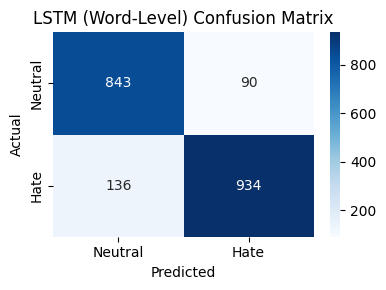

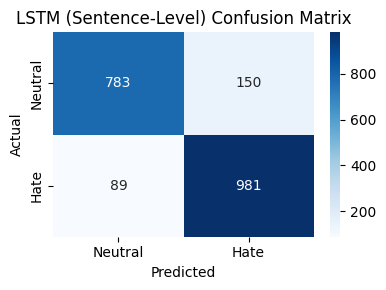

In [13]:
# Confusion Matrix helper
# =========================
def plot_confusion_matrix_(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neutral', 'Hate'],
                yticklabels=['Neutral', 'Hate'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Example plots:
plot_confusion_matrix_(y_test, y_pred_word, "LSTM (Word-Level) Confusion Matrix")
plot_confusion_matrix_(y_test, y_pred_sent, "LSTM (Sentence-Level) Confusion Matrix")



[Ensemble] Word-Level (TF-IDF) — Soft Voting
              precision    recall  f1-score   support

           0     0.8901    0.8682    0.8790       933
           1     0.8875    0.9065    0.8969      1070

    accuracy                         0.8887      2003
   macro avg     0.8888    0.8874    0.8880      2003
weighted avg     0.8887    0.8887    0.8886      2003

Accuracy: 0.8887


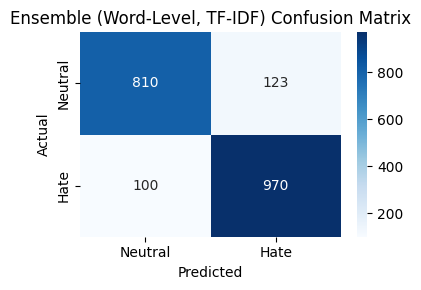

In [14]:
# ENSEMBLE: Word-Level (TF-IDF) — Soft Voting (LR + SVM + RF)
# =========================
lr_w = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
svm_w = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)  # probability=True for soft vote
rf_w  = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)

word_ens = VotingClassifier(
    estimators=[('lr', lr_w), ('svm', svm_w), ('rf', rf_w)],
    voting='soft', n_jobs=-1
)

word_ens.fit(X_train_tfidf, y_train)
y_pred_word_ens = word_ens.predict(X_test_tfidf)

print("\n[Ensemble] Word-Level (TF-IDF) — Soft Voting")
print(classification_report(y_test, y_pred_word_ens, digits=4))
print("Accuracy:", round(accuracy_score(y_test, y_pred_word_ens), 4))

plot_confusion_matrix_(y_test, y_pred_word_ens, "Ensemble (Word-Level, TF-IDF) Confusion Matrix")



[Ensemble] Sentence-Level (Embeddings) — Soft Voting
              precision    recall  f1-score   support

           0     0.8145    0.8564    0.8349       933
           1     0.8689    0.8299    0.8489      1070

    accuracy                         0.8422      2003
   macro avg     0.8417    0.8431    0.8419      2003
weighted avg     0.8435    0.8422    0.8424      2003

Accuracy: 0.8422


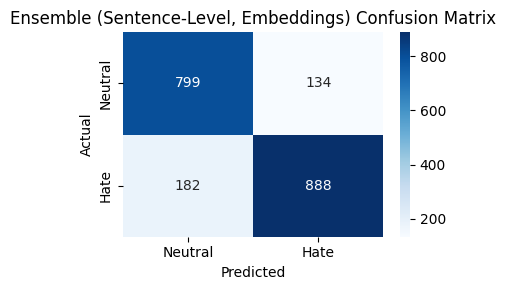

In [15]:
# ENSEMBLE: Sentence-Level (Embeddings) — Soft Voting (LR + SVM + MLP)
# =========================
lr_s = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
svm_s = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)  # probability=True for soft vote
mlp_s = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=500, random_state=42)

sent_ens = VotingClassifier(
    estimators=[('lr', lr_s), ('svm', svm_s), ('mlp', mlp_s)],
    voting='soft', n_jobs=-1
)

sent_ens.fit(X_train_sentence_embeddings, y_train)
y_pred_sent_ens = sent_ens.predict(X_test_sentence_embeddings)

print("\n[Ensemble] Sentence-Level (Embeddings) — Soft Voting")
print(classification_report(y_test, y_pred_sent_ens, digits=4))
print("Accuracy:", round(accuracy_score(y_test, y_pred_sent_ens), 4))

plot_confusion_matrix_(y_test, y_pred_sent_ens, "Ensemble (Sentence-Level, Embeddings) Confusion Matrix")


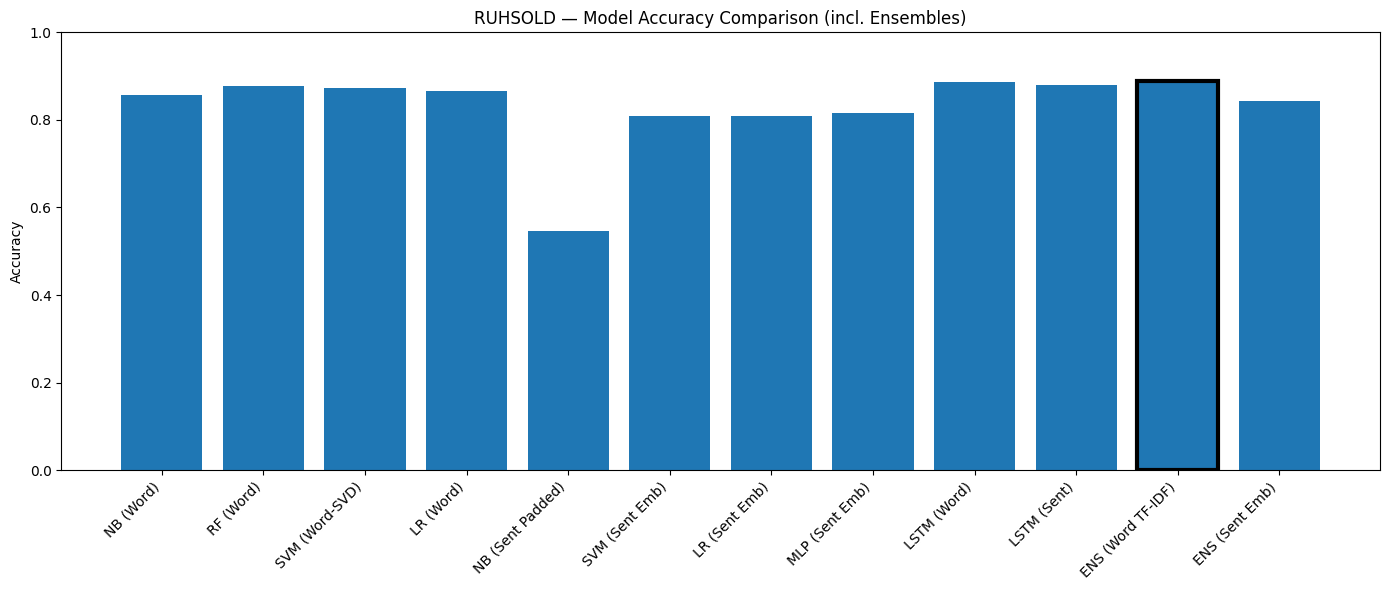

In [16]:
# Summary Plot — Model Accuracies (example)
# =========================
model_names = [
    'NB (Word)', 'RF (Word)', 'SVM (Word-SVD)', 'LR (Word)',
    'NB (Sent Padded)', 'SVM (Sent Emb)', 'LR (Sent Emb)', 'MLP (Sent Emb)',
    'LSTM (Word)', 'LSTM (Sent)',
    'ENS (Word TF-IDF)', 'ENS (Sent Emb)'
]

# capture accuracies (re-run models above to get these vars if needed)
# For NB/SVM/LR/RF we captured inside train_and_evaluate_model but not returned; run quick predictions again to collect:
def quick_acc(model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    return accuracy_score(yte, model.predict(Xte))

acc_nb_word  = quick_acc(MultinomialNB(), X_train_tfidf, y_train, X_test_tfidf, y_test)
acc_rf_word  = quick_acc(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
                         X_train_tfidf, y_train, X_test_tfidf, y_test)
acc_svm_word = quick_acc(SVC(kernel='linear', class_weight='balanced', random_state=42),
                         X_train_reduced, y_train, X_test_reduced, y_test)
acc_lr_word  = quick_acc(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                         X_train_tfidf, y_train, X_test_tfidf, y_test)

acc_nb_sent  = quick_acc(MultinomialNB(), X_train_padded, y_train, X_test_padded, y_test)
acc_svm_sent = quick_acc(SVC(kernel='linear', class_weight='balanced', random_state=42),
                         X_train_sentence_embeddings, y_train, X_test_sentence_embeddings, y_test)
acc_lr_sent  = quick_acc(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                         X_train_sentence_embeddings, y_train, X_test_sentence_embeddings, y_test)
acc_mlp_sent = quick_acc(MLPClassifier(hidden_layer_sizes=(128,64), activation='relu', max_iter=500, random_state=42),
                         X_train_sentence_embeddings, y_train, X_test_sentence_embeddings, y_test)

# LSTM accs already computed: acc_w, acc_s
acc_ens_word = accuracy_score(y_test, y_pred_word_ens)
acc_ens_sent = accuracy_score(y_test, y_pred_sent_ens)

accuracies = [
    acc_nb_word, acc_rf_word, acc_svm_word, acc_lr_word,
    acc_nb_sent, acc_svm_sent, acc_lr_sent, acc_mlp_sent,
    acc_w, acc_s,
    acc_ens_word, acc_ens_sent
]

plt.figure(figsize=(14, 6))
bars = plt.bar(model_names, accuracies)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.ylabel('Accuracy')
plt.title('RUHSOLD — Model Accuracy Comparison (incl. Ensembles)')
# highlight best
best_idx = int(np.argmax(accuracies))
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(3)
plt.tight_layout()
plt.show()